## Econometrics - BSc AIDAMS

Prof. Roberto Renò - ESSEC Business School 

## Homework 1

# Infos 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
data = pd.read_csv("bwages.csv")

In [4]:
data.head()

,WAGE,LNWAGE,EDUC,EXPER,LNEXPER,LNEDUC,MALE
0,7.780208,2.051583,1,23,3.178054,0.0,1
1,4.818505,1.572464,1,15,2.772589,0.0,0
2,10.563645,2.357418,1,31,3.465736,0.0,1
3,7.042429,1.951953,1,32,3.496508,0.0,1
4,7.887521,2.065282,1,9,2.302585,0.0,1


## Explaining wages

We model individual wages using a cross-sectional data set of 1472 observations. The dataset is called BWAGES and the variables we use are:

• wage: hourly wage rate in euros per hous
• male: 1 if male, 0 if female
• educ: education level, 1 = primary school, 2 = lower vocational training, 3 = intermediate level, 4 = higher vocational training, 5 = university level
• exper: experience in years

## Questions 

Part A

1. Compute standard descriptive statistics for the variables involved in this study.
2. Prepare extra columns in the data dataframe with dummy variables: educ1=1 if primary school, 0 otherwise; educ2=1 if lower vocational training, 0 otherwise, and so on.
3. Estimate the following model by OLS: wage = β0 + β1male + β2educ1 + β3educ2 + β3educ3 + β4educ4 + β5exper + ε, and show the coefficients.
4. Why is there no educ5 in the model? Explain.
5. What is the expected salary for a man with university level education?
6. What is the expected salary for a man with university level education?
7. Using standard t-tests, are the explanatory variables significant?
8. Is there a significant salary difference between men and woman according to the above model?
9. Add squared experience as an additional variable in your model, estimate it again, and show the new results.
10. What is the impact of experience on wage? Write a short comment based on the statistical significance of the above estimate.

Part B

The above model did not have any interaction effect between gender and education. Let's add it.

11. Write down a model that explicitly incorporates an interaction effect between gender and education.
12. Estimate this new model using OLS and show the coefficients.
13. Test for differences between men and woman in this general model.
14. Demonstrate empirically that the sum of squared residuals (SSR) for this general model is equal to the SSR of the model explaining wage by the educ dummies and the experience variables fitted to the sample of men + the SSR of the same model fitted to the sample of woman.

Part C

15. Display the the distribution of the residuals ε in the model in point 3. 
16. Compute the sum of estimated residuals, and write a comment about the result.
17. How much is the correlation between estimated residuals and exper? Explain the result that you get.
18. Compute the skewness and the kurtosis of the estimated residuals and write an appropriate comment about the result.
19. Test if the distribution of estimated residuals is Gaussian (select your favourite test and comment accurately the result of the test).
20. What should you change in this study if the residuals are not Gaussian?




# Part A

## 1) 


In [5]:
data[['WAGE','MALE','EDUC','EXPER']].describe()

,WAGE,MALE,EDUC,EXPER
count,1472.000000,1472.000000,1472.000000,1472.000000
mean,11.050616,0.606658,3.378397,17.217391
std,4.450513,0.488658,1.204522,10.166675
min,2.190978,0.000000,1.000000,0.000000
25%,8.112878,0.000000,3.000000,9.000000
50%,10.126653,1.000000,3.000000,16.500000
75%,12.755447,1.000000,4.000000,24.000000
max,47.575527,1.000000,5.000000,47.000000


In [6]:
data[['WAGE','MALE','EDUC','EXPER']].median()

WAGE     10.126653
MALE      1.000000
EDUC      3.000000
EXPER    16.500000
dtype: float64

The median hourly wage is approximately €10.13, slightly below the mean. The typical individual in the sample is male, has a mid-level education (level 3), and around 16.5 years of labor market experience.”

## 2)

In [7]:
dummies = pd.get_dummies(data['EDUC'], prefix='EDUC').astype(int)
data = pd.concat([data, dummies], axis=1)
data.head()

,WAGE,LNWAGE,EDUC,EXPER,LNEXPER,LNEDUC,MALE,EDUC_1,EDUC_2,EDUC_3,EDUC_4,EDUC_5
0,7.780208,2.051583,1,23,3.178054,0.0,1,1,0,0,0,0
1,4.818505,1.572464,1,15,2.772589,0.0,0,1,0,0,0,0
2,10.563645,2.357418,1,31,3.465736,0.0,1,1,0,0,0,0
3,7.042429,1.951953,1,32,3.496508,0.0,1,1,0,0,0,0
4,7.887521,2.065282,1,9,2.302585,0.0,1,1,0,0,0,0


## 3)

In [12]:

X = data[['MALE', 'EDUC_1', 'EDUC_2', 'EDUC_3', 'EDUC_4', 'EXPER']]
X = sm.add_constant(X)

y = data['WAGE']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   WAGE   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     141.5
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          1.29e-141
Time:                        09:49:57   Log-Likelihood:                -3949.4
No. Observations:                1472   AIC:                             7913.
Df Residuals:                    1465   BIC:                             7950.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4010      0.260     40.012      0.000       9.891      10.911
MALE           1.3009      0.195      6.682      0.000       0.919       1.683
EDUC_1        -7.9049      0.421    -18.778      0.000      -8.731      -7.079
EDUC_2        -6.0897      0.299    -20.384      0.000      -6.676      -5.504
EDUC_3        -4.2446      0.262    -16.223      0.000      -4.758      -3.731
EDUC_4        -2.4175      0.272     -8.882      0.000      -2.951      -1.884
EXPER          0.1907      0.010     19.779      0.000       0.172       0.210
==============================================================================
Omnibus:                      577.393   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5122.559
Skew:                           1.580   Prob(JB):                         0.00
Kurtosis:                      11.575   Cond. No.                         109.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The regression results indicate that wages increase with experience, with each additional year raising hourly earnings by approximately €0.19. Being male is associated with a higher wage of about €1.30 per hour compared to females. Education has a strong positive effect: individuals with lower education levels earn significantly less than those with university education (the reference group), with the gap decreasing as the level of education rises. This pattern suggests a clear return to education, where higher educational attainment is associated with higher wages.

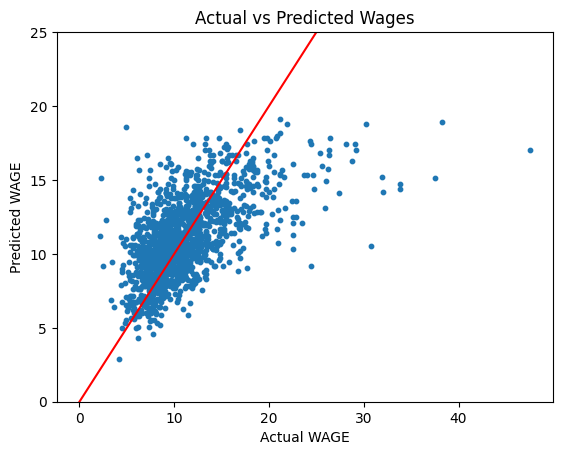

In [13]:
y_pred = model.predict(X)

plt.figure()

# scatter with smaller blue points
plt.scatter(y, y_pred, s=10)

# red perfect fit line
plt.plot([0, 25], [0, 25], color='red')

# limit predicted wages to 25
plt.ylim(0, 25)

plt.xlabel('Actual WAGE')
plt.ylabel('Predicted WAGE')
plt.title('Actual vs Predicted Wages')

plt.show()

## 4 )

We can not use every varaiable since they are exhausitve, using every one would result in : educ1 + educ2 + educ3 + educ4 + educ5 = 1. A perfect multicolinearity 

## 5 & 6 )

In [16]:
exp_mean = data['EXPER'].mean()

pred_man_university = model.predict([[1, 1, 0, 0, 0, 0, exp_mean]])[0]
pred_woman_university = model.predict([[1, 0, 0, 0, 0, 0, exp_mean]])[0]
pred_man_educ1 = model.predict([[1, 1, 1, 0, 0, 0, exp_mean]])[0]

print("Expected wage for a man with university education:", pred_man_university)
print("Expected wage for a woman with university education:", pred_woman_university)
print("Expected wage for a man with primary school education (educ1):", pred_man_educ1)

Expected wage for a man with university education: 14.986024789179835
Expected wage for a woman with university education: 13.685120224386232
Expected wage for a man with primary school education (educ1): 7.081098842255053


The predicted hourly wage is approximately €14.99 for a man with university education,
€13.69 for a woman with university education, 
and €7.08 for a man with only primary school education.

## 7)

As shown in Question 3, all estimated coefficients are associated with p-values equal to 0.000, indicating that the null hypothesis of no effect can be rejected for each explanatory variable. This implies that all variables included in the model—gender, education levels, and experience—are statistically significant determinants of wages. Therefore, each variable contributes meaningfully to explaining wage variation in the sample.

## 8)

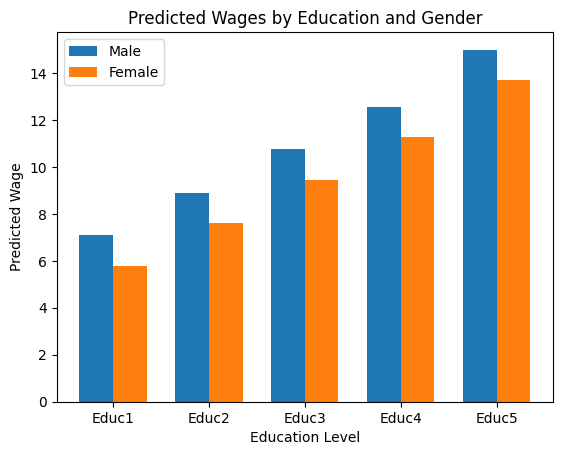

In [17]:
# Average experience
exp_mean = data['EXPER'].mean()

# Store predictions
educ_levels = [1, 2, 3, 4, 5]
male_preds = []
female_preds = []

for e in educ_levels:
    # Create dummy values
    educ_dummies = [0, 0, 0, 0]  # EDUC_1 to EDUC_4
    
    if e != 5:  # if not university (reference)
        educ_dummies[e-1] = 1

    # Male prediction
    male = [1, 1] + educ_dummies + [exp_mean]
    male_preds.append(model.predict([male])[0])

    # Female prediction
    female = [1, 0] + educ_dummies + [exp_mean]
    female_preds.append(model.predict([female])[0])

# Plot
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(educ_levels))
width = 0.35

plt.figure()

plt.bar(x - width/2, male_preds, width, label='Male')
plt.bar(x + width/2, female_preds, width, label='Female')

plt.xticks(x, ['Educ1', 'Educ2', 'Educ3', 'Educ4', 'Educ5'])
plt.xlabel('Education Level')
plt.ylabel('Predicted Wage')
plt.title('Predicted Wages by Education and Gender')
plt.legend()

plt.show()

There is a statistically significant salary difference between men and women. The estimated coefficient on the male variable is positive and highly significant (p-value = 0.000), indicating that men earn approximately €1.30 more per hour than women( from q3), holding education and experience constant. This result is consistent with the graphical analysis, which shows that for every level of education, predicted wages for men are systematically higher than those for women, confirming the presence of a persistent gender wage gap.

## 9)

In [18]:
# Create squared experience
data['EXPER2'] = data['EXPER']**2

# New regression with EXPER²
X = data[['MALE', 'EDUC_1', 'EDUC_2', 'EDUC_3', 'EDUC_4', 'EXPER', 'EXPER2']]
X = sm.add_constant(X)

y = data['WAGE']

model2 = sm.OLS(y, X).fit()

model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   WAGE   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     128.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          3.36e-147
Time:                        10:54:52   Log-Likelihood:                -3933.8
No. Observations:                1472   AIC:                             7884.
Df Residuals:                    1464   BIC:                             7926.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3200      0.322     28.956      0.000       8.689       9.951
MALE           1.2848      0.193      6.666      0.000       0.907       1.663
EDUC_1        -7.8258      0.417    -18.770      0.000      -8.644      -7.008
EDUC_2        -6.1481      0.296    -20.778      0.000      -6.729      -5.568
EDUC_3        -4.3018      0.259    -16.597      0.000      -4.810      -3.793
EDUC_4        -2.4622      0.270     -9.135      0.000      -2.991      -1.933
EXPER          0.3595      0.032     11.354      0.000       0.297       0.422
EXPER2        -0.0045      0.001     -5.591      0.000      -0.006      -0.003
==============================================================================
Omnibus:                      594.123   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5377.287
Skew:                           1.630   Prob(JB):                         0.00
Kurtosis:                      11.777   Cond. No.                     3.11e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 10)

The impact of experience on wages is positive but diminishing. The coefficient on experience is positive and statistically significant, while the coefficient on squared experience is negative and also significant. This indicates that wages increase with experience at a decreasing rate, meaning that the return to additional years of experience declines over time. Eventually, the effect may even turn negative after a certain level of experience, reflecting a concave relationship between experience and wages

# Part B

# Part C